# Lesson 1.1 — Differential Translation and Rotation
**Module 6 · Unit 1 · Lesson 1**

This notebook verifies, numerically, the three core claims of the lesson:

1. A differential rotation is $R \approx I + S(\delta\boldsymbol\theta)$, with error **second-order** in the angle.
2. To first order, differential rotations **commute**.
3. Differential rotation vectors **add like vectors**.

It closes by reconnecting to Module 5: the end-effector differential motion of a 2R arm equals $J\,\Delta\boldsymbol\theta$ to first order — the same $\Delta\mathbf p \approx J\,\Delta\boldsymbol\theta$ the M5 IK solver used.

Convention (D-057): twist ordering $\xi=[v;\omega]$, base/world frame. This lesson uses only the rotational pieces; the full twist arrives in Lesson 1.3.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

checks = []  # every claim appends a boolean; the final cell asserts all are True

def skew(v):
    # Skew-symmetric operator S(v):  S(v) @ u == v x u
    v = np.asarray(v, float).ravel()
    return np.array([[0.0, -v[2],  v[1]],
                     [v[2],  0.0, -v[0]],
                     [-v[1], v[0],  0.0]])

# sanity: S(v) u == v x u
for _ in range(5):
    a, b = np.random.randn(3), np.random.randn(3)
    assert np.allclose(skew(a) @ b, np.cross(a, b))
checks.append(True)
print("skew operator verified:  S(v) u = v x u")

skew operator verified:  S(v) u = v x u


## 1. Differential rotation: $R \approx I + S(\delta\boldsymbol\theta)$, error is second-order

In [2]:
def R_exact(k, ang):
    # Exact rotation about axis k by angle ang (Rodrigues' formula)
    k = np.asarray(k, float); k = k / np.linalg.norm(k)
    K = skew(k)
    return np.eye(3) + np.sin(ang) * K + (1 - np.cos(ang)) * (K @ K)

def R_diff(dtheta):
    # Differential (first-order) rotation:  I + S(dtheta)
    return np.eye(3) + skew(dtheta)

k = np.array([0, 0, 1.0])
angles = np.array([1e-1, 1e-2, 1e-3, 1e-4])
errs = np.array([np.linalg.norm(R_exact(k, a) - R_diff(a * k)) for a in angles])

for a, e in zip(angles, errs):
    print(f"angle = {a:.0e} rad   ||R_exact - R_diff|| = {e:.3e}")

# error ~ angle^2  => over 3 decades of angle, ~6 decades of error
decades = np.log10(errs[0] / errs[-1])
print(f"\nerror shrinks by ~{decades:.1f} decades over 3 decades of angle (expect ~6 => slope 2)")
checks.append(np.isclose(decades, 6.0, atol=0.5))

angle = 1e-01 rad   ||R_exact - R_diff|| = 7.069e-03
angle = 1e-02 rad   ||R_exact - R_diff|| = 7.071e-05
angle = 1e-03 rad   ||R_exact - R_diff|| = 7.071e-07
angle = 1e-04 rad   ||R_exact - R_diff|| = 7.071e-09

error shrinks by ~6.0 decades over 3 decades of angle (expect ~6 => slope 2)


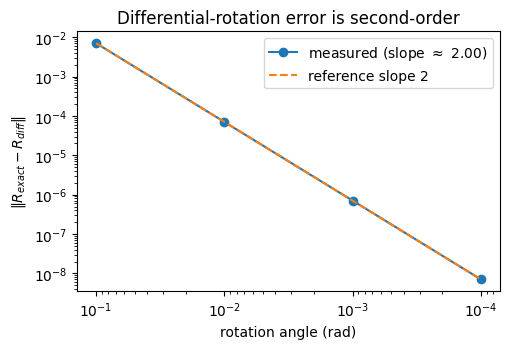

In [3]:
# Visualize the second-order scaling on log-log axes
slope = np.polyfit(np.log10(angles), np.log10(errs), 1)[0]
plt.figure(figsize=(5.2, 3.6))
plt.loglog(angles, errs, 'o-', label=f'measured (slope $\\approx$ {slope:.2f})')
plt.loglog(angles, errs[0] * (angles / angles[0])**2, '--', label='reference slope 2')
plt.gca().invert_xaxis()
plt.xlabel('rotation angle (rad)'); plt.ylabel(r'$\|R_{exact}-R_{diff}\|$')
plt.title('Differential-rotation error is second-order'); plt.legend(); plt.tight_layout()
plt.show()
checks.append(abs(slope - 2.0) < 0.2)

## 2. Differential rotations commute (to first order); finite ones do not

In [4]:
da = db = 1e-3
# first-order (linear) parts are order-independent:
linear_xy = skew([da, 0, 0]) + skew([0, db, 0])
linear_yx = skew([0, db, 0]) + skew([da, 0, 0])
checks.append(np.allclose(linear_xy, linear_yx))
print("first-order parts commute:", np.allclose(linear_xy, linear_yx))

# full finite commutator is second-order, O(da*db):
comm_small = R_exact([1,0,0], da) @ R_exact([0,1,0], db) - R_exact([0,1,0], db) @ R_exact([1,0,0], da)
print(f"||commutator|| at 1e-3 rad = {np.linalg.norm(comm_small):.3e}  (~ da*db = {da*db:.0e})")
checks.append(np.linalg.norm(comm_small) < 10 * da * db)

# but at 90 degrees the two orders are completely different:
Rx90, Ry90 = R_exact([1,0,0], np.pi/2), R_exact([0,1,0], np.pi/2)
comm_big = Rx90 @ Ry90 - Ry90 @ Rx90
print(f"||commutator|| at 90 deg   = {np.linalg.norm(comm_big):.3f}  (finite rotations do NOT commute)")
checks.append(np.linalg.norm(comm_big) > 1.0)

first-order parts commute: True
||commutator|| at 1e-3 rad = 1.414e-06  (~ da*db = 1e-06)
||commutator|| at 90 deg   = 2.449  (finite rotations do NOT commute)


## 3. Differential rotation vectors add like vectors

In [5]:
d1 = np.array([1e-3, 0, 0])
d2 = np.array([0, 2e-3, 0])
combined = R_diff(d2) @ R_diff(d1)     # apply d1 then d2
added    = R_diff(d1 + d2)             # just add the rotation vectors
err = np.linalg.norm(combined - added)
print(f"||(I+S(d2))(I+S(d1)) - (I+S(d1+d2))|| = {err:.3e}  (second-order residual)")
checks.append(err < 1e-5)

||(I+S(d2))(I+S(d1)) - (I+S(d1+d2))|| = 2.000e-06  (second-order residual)


## 4. Reconnecting to Module 5: end-effector differential motion = $J\,\Delta\boldsymbol\theta$

The M5 numerical IK solver iterated on $\Delta\mathbf p \approx J\,\Delta\boldsymbol\theta$. That approximation *is* differential motion. Here we confirm it for a planar 2R arm.

In [6]:
L1 = L2 = 1.0
def fk(theta):
    t1, t2 = theta
    return np.array([L1*np.cos(t1) + L2*np.cos(t1+t2),
                     L1*np.sin(t1) + L2*np.sin(t1+t2)])

def jacobian(theta):
    t1, t2 = theta
    s1, s12 = np.sin(t1), np.sin(t1+t2)
    c1, c12 = np.cos(t1), np.cos(t1+t2)
    return np.array([[-L1*s1 - L2*s12, -L2*s12],
                     [ L1*c1 + L2*c12,  L2*c12]])

theta = np.array([0.5, 0.7])
dtheta = np.array([1e-4, -1e-4])           # a *differential* joint move
dp_exact = fk(theta + dtheta) - fk(theta)  # true end-effector displacement
dp_lin   = jacobian(theta) @ dtheta        # first-order prediction  J * dtheta
print("dp_exact =", dp_exact)
print("dp_lin   =", dp_lin)
print(f"residual = {np.linalg.norm(dp_exact - dp_lin):.3e}")
checks.append(np.linalg.norm(dp_exact - dp_lin) < 1e-7)

dp_exact = [-4.79469417e-05  8.77558589e-05]
dp_lin   = [-4.79425539e-05  8.77582562e-05]
residual = 5.000e-09


## Final check

In [7]:
assert all(checks), f"Some checks FAILED: {checks}"
print("All checks passed.")

All checks passed.
